In [8]:
import matplotlib.pyplot as plt
from torch import nn
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import math
import warnings
import torchvision
import numpy as np
from scipy import interpolate
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import SplineTransformer
from collections import OrderedDict


In [9]:
def sim_data(n, dim, Type):
	if Type == 'A':
		X = torch.rand((n,2))
		y = torch.exp(2*torch.sin(X[:,0]*0.5*torch.pi)+ 0.5*torch.cos(X[:,1]*2.5*torch.pi))
		y = y.reshape(-1,1)
		y = y.float()
		
	elif Type == 'B':
		X = torch.rand((n, dim))
		y = 1
		for d in range(dim):
			a = (d+1)/2
			y *= ((torch.abs(4*X[:,d]-2)+a)/(1+a))
		y = y.reshape(-1,1)
		y = y.float()
	else:
		pass
	
	return X, y

ndim = 2
torch.manual_seed(0)
X_train, y_train = sim_data(400, ndim, 'A')
X_test, y_test = sim_data(400, ndim, 'A')
epstrain = torch.normal(0, 0.1, size=y_train.size())
epstest = torch.normal(0, 0.1, size=y_test.size())

y_train, y_test = y_train + epstrain, y_test + epstest

In [ ]:
import torch
import torch.nn as nn

class NormLayer(nn.Module):
    def __init__(self):
        super(NormLayer, self).__init__()

    def forward(self, x):
        min_val = torch.min(x, dim=1, keepdim=True).values
        max_val = torch.max(x, dim=1, keepdim=True).values
        
        x = (x - min_val) / (max_val - min_val + 1e-6)
        return x

class BSL(nn.Module):
    def __init__(self, degree, num_knots, num_neurons, bias = True):
        super(BSL, self).__init__()
        self.degree = degree
        self.num_knots = num_knots
        self.num_neurons = num_neurons
        self.control_p = nn.Parameter(torch.randn(self.num_knots, self.num_neurons))
        
        if bias:
            self.bias = nn.Parameter(torch.randn(self.num_neurons))
        else:
            self.register_parameter('bias', None)
            
        self.inter = {}


    def knots_distribution(self, dg, nk):

        knots = torch.cat([torch.linspace(0, 0.001, steps=dg),            # Add repeated values at the start for clamping
            torch.linspace(0.002, 0.998, nk-2*dg-2),  # Uniform knot spacing in the middle
            torch.linspace(0.999, 1.000, steps=dg)           # Add repeated values at the end for clamping
            ]).view(-1,1)
     
        return knots
    
    def basis_function(self, x, spl):
        basis_output = spl.fit_transform(x.detach().numpy())
        return basis_output
            
    def forward(self, x):
        batch_size, num_features = x.size()
        device = x.device
        
        # Create knot vector and apply B-spline basis functions for each feature
    
        basises = []
        knots = self.knots_distribution(self.degree, self.num_knots)
        #knots = knots.to(device)
        spl = SplineTransformer(n_knots=self.num_knots, degree=self.degree, knots = knots)

        
        for feature in range(num_features):
            # Calculate B-spline basis functions for this feature
            
            basis = self.basis_function(x[:, feature].reshape(-1,1), spl)
            basis = torch.Tensor(basis).to(device)
            basises.append(basis)
        
        self.inter['basic'] = torch.reshape(torch.stack(basises, dim = 1), (batch_size, self.num_knots * self.num_neurons)).T
        basises = torch.stack(basises)
        tout = basises.permute(1,2,0) * self.control_p
        tout = tout.sum(dim =1)
        if self.bias is not None:
            tout += self.bias        
            
        return tout 
    
class BSpline_block(nn.Module):
    def __init__(self, degree, num_knots, num_neurons, dropout = 0.0, bias = True):
        super(BSpline_block, self).__init__()

        self.block = nn.Sequential(OrderedDict([
            ('norm', NormLayer()),
            ('BSL', BSL(degree = degree, num_knots = num_knots, num_neurons = num_neurons, bias = bias)),
            ('drop', nn.Dropout(dropout)),
        ]))
        
    def forward(self, x):
        return self.block(x)
    
class StackBS_block(nn.Module):
    def __init__(self, block, degree, num_knots, num_neurons, num_blocks, dropout = 0.0, bias = True):
        super().__init__()
        self.model = nn.ModuleDict({
            f'block_{i}': block(degree = degree, num_knots = num_knots, num_neurons = num_neurons)
            for i in range(num_blocks)
        })

    def forward(self, x):
        for name, block in self.model.items():
            x = block(x)
        return x
    
class DPS(nn.Module):
    def __init__(self, input_dim, degree, num_knots, num_neurons, num_bsl, dropout, output_dim, bias):
        super(DPS, self).__init__()
        self.num_neurons = num_neurons
        self.num_knots = num_knots
        self.ln1 = nn.Linear(input_dim, num_neurons)
        self.Spline_block = StackBS_block(BSpline_block, degree = degree, num_knots = num_knots, num_neurons = num_neurons, num_blocks = num_bsl, dropout = dropout)
        self.ln2 = nn.Linear(num_neurons, output_dim)
        
    def forward(self, x):
        
        x = self.ln1(x)
        spout = self.Spline_block(x)
        output = self.ln2(spout)
        
        return output

    def get_para_ecm(self, x):

        '''
        ecm_para: A dictionary that collects the parameter we need to the following ECM algorithm.
        ecm_para.basic: Store the output of each B-Spline block; Dimension = [n_sample, n_neurons]
        ecm_para.ebasic Store the weight matrix of each B-Spline expansion; Dimension = [n_knots * n_neurons, n_sample]

        '''
        ecm_para = {}
        bs_block_out = {}
        bs_spline_weight = {}
        bs_spline_value = {}
        bs_spline_bias = {}

        _ = self(x)
        
        def get_activation(name):
            def hook(model, input, output):
                bs_block_out[name] = output.detach()
            return hook

        handles = []
        for name, layer in self.named_modules():
            if 'block.drop' in name:
                handles.append(layer.register_forward_hook(get_activation(name)))
            elif 'block.BSL' in name:
                bs_spline_value[name] = layer.inter['basic'].detach()
                bs_spline_weight[name] = layer.control_p.detach()
                bs_spline_bias[name] = layer.bias.detach()
        # Run forward pass (triggers hooks)
        _ = self(x)

        # Clean up hooks
        for h in handles:
            h.remove()
            
        ecm_para['basic'] = torch.stack(list(bs_block_out.values()), dim=0)
        ecm_para['ebasic'] = torch.stack(list(bs_spline_value.values()), dim=0)
        ecm_para['wbasic'] = torch.stack(list(bs_spline_weight.values()), dim=0)
        ecm_para['bbasic'] = torch.stack(list(bs_spline_bias.values()), dim=0)
        del bs_block_out, bs_spline_weight, bs_spline_value, bs_spline_bias
        
        return ecm_para

    def fit(self, x):
        return 0
    
def num_para(model):
    tp = 0
    for param in model.parameters():
        tp += param.numel()
    return tp

In [36]:
torch.var(y_train)*0.01

tensor(0.0947)

In [66]:
nk = 15; nm = 50; nl = 2; Fout = 1; device = "cpu"
model = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = nm, num_bsl = nl, dropout = 0.0, output_dim = Fout, bias = True).to(device)
print('Number of Parameters: ', num_para(model))

learning_r = 1e-1
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=learning_r)
Iteration = 10000; bloss_list = []; tor = 1e-5; lr_tor = 1e-6
patientc = 10; patientr = 5; tpat = 0; bloss = np.inf

Number of Parameters:  1801


In [67]:
for t in range(Iteration):
    model.train()
    # Forward pass: Compute predicted y by passing x to the modelsp
    pyb_af = model(X_train)
    loss = criterion(y_train, pyb_af); bloss_list.append(loss.item())
    
    if (t > 0) and ((bloss_list[t-1]-bloss_list[t])<tor):        
        if (tpat != 0) and (tpat != 0) and (tpat % patientr) == 0:
            learning_r *= 0.2 
            tpat += 1
            #print('Learning rate reduce to ', learning_r)
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_r)
            if learning_r <= lr_tor:
                print('Convergence!')
                break
        elif tpat < patientc:
            tpat += 1
            pass
        else:
            print('Convergence!')
            break
        
    else:
        if loss < bloss:
            #print('Current loss: ', loss.item(), ' | , previous best loss: ', bloss, ' | saving best model ...')
            torch.save(model.state_dict(), './EXB'+str(X_train.size()[0])+'h'+str(nm)+'k'+str(nk))
            bloss = loss.item()
            tpat = 0
        else:
            tpat += 1

    if tpat == patientc:
        print('Convergence!')
        break
        
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print('| Epoch: ',t+1,'/',str(Iteration),' | Loss: ', np.round(loss.item(), 4),' |')

| Epoch:  1 / 10000  | Loss:  21.399  |
| Epoch:  2 / 10000  | Loss:  12.0818  |
| Epoch:  3 / 10000  | Loss:  13.5861  |
| Epoch:  4 / 10000  | Loss:  7.5762  |
| Epoch:  5 / 10000  | Loss:  7.5442  |
| Epoch:  6 / 10000  | Loss:  8.484  |
| Epoch:  7 / 10000  | Loss:  5.9932  |
| Epoch:  8 / 10000  | Loss:  3.6608  |
| Epoch:  9 / 10000  | Loss:  3.9122  |
| Epoch:  10 / 10000  | Loss:  4.6183  |
| Epoch:  11 / 10000  | Loss:  3.5938  |
| Epoch:  12 / 10000  | Loss:  2.3339  |
| Epoch:  13 / 10000  | Loss:  2.5945  |
| Epoch:  14 / 10000  | Loss:  3.5102  |
| Epoch:  15 / 10000  | Loss:  3.3762  |
| Epoch:  16 / 10000  | Loss:  2.5851  |
| Epoch:  17 / 10000  | Loss:  2.3959  |
| Epoch:  18 / 10000  | Loss:  2.8047  |
| Epoch:  19 / 10000  | Loss:  2.1543  |
| Epoch:  20 / 10000  | Loss:  2.3223  |
| Epoch:  21 / 10000  | Loss:  2.1112  |
| Epoch:  22 / 10000  | Loss:  1.7923  |
| Epoch:  23 / 10000  | Loss:  1.6501  |
| Epoch:  24 / 10000  | Loss:  1.6761  |
| Epoch:  25 / 10000  | 

(Train) MSPE:  tensor(0.0800) | (Test) MSPE:  tensor(0.1230)


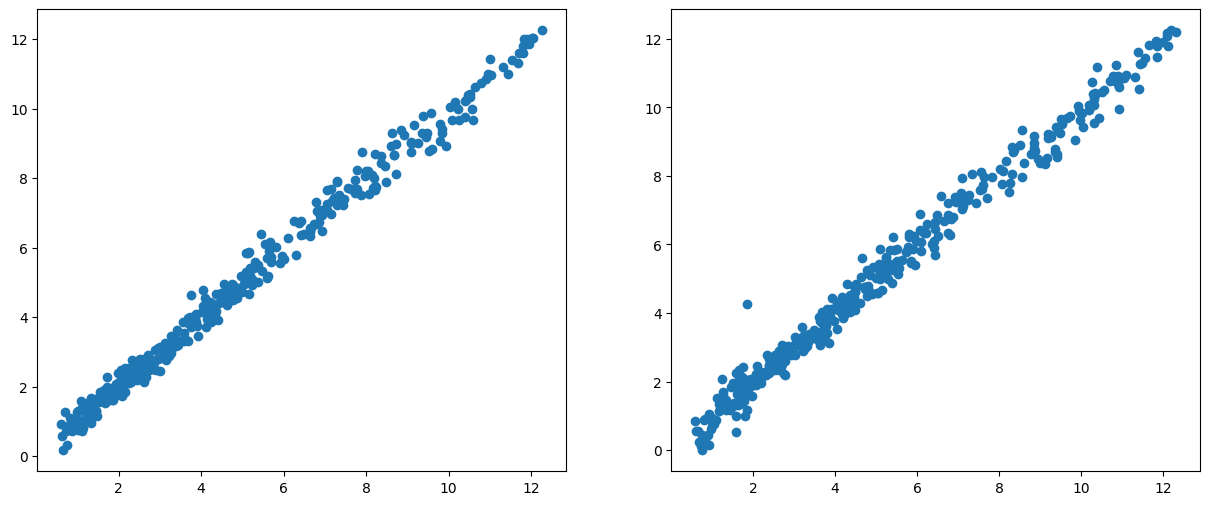

In [68]:
with torch.no_grad():
    eval_model = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = nm, num_bsl = nl, dropout = 0.0, output_dim = Fout, bias = True).to(device)
    eval_model.load_state_dict(torch.load('./EXB'+str(X_train.size()[0])+'h'+str(nm)+'k'+str(nk), weights_only = True))
    eval_model.eval()
    print('(Train) MSPE: ',criterion(y_train, eval_model(X_train).detach()), '| (Test) MSPE: ',criterion(y_test, eval_model(X_test).detach()))
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    plt.scatter(y_train, eval_model(X_train).detach())
    plt.subplot(1,2,2)
    plt.scatter(y_test, eval_model(X_test).detach())

torch.Size([400, 2])